<a href="https://colab.research.google.com/github/gustkt/GE337_Programming_Dev/blob/main/Lab_4_%E0%B8%81%E0%B8%A4%E0%B8%95%E0%B8%A0%E0%B8%B2%E0%B8%AA_6606614615.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab 4: การพัฒนาแบบจำลอง Machine Learning สำหรับการจำแนกพื้นที่ป่าด้วยข้อมูลภาพถ่ายดาวเทียม**

**ข้อมูลที่ใช้**
* ข้อมูล Raster : ภาพถ่ายดาวเทียม Sentinel-2 หรือ Landsat-8 (Band ที่สำคัญ เช่น Red, NIR,
Green, SWIR)
* ข้อมูลเวกเตอร์ : จุดตัวอย่างของพื้นที่แต่ละประเภท เช่น พื้นที่สีเขียว เขตเมือง แหล่งน้ำ (จาก CSV )

**การเตรียมข้อมูล**

In [1]:
# # GEE & Geemap
# import ee
# import geemap

# ee.Authenticate()
# ee.Initialize(project='ee-gustkt45513')

In [2]:
# จัดการ Raster และ Vector
import rasterio
from rasterio.plot import show # ใช้สำหรับพล็อตภาพ Raster ง่ายๆ
from rasterio.transform import rowcol
from rasterio.warp import transform_bounds
from rasterio.features import geometry_mask
import geopandas as gpd
import pandas as pd

# Machine Learning (Scikit-Learn)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

import gc

# Visualization
from matplotlib import colors
import matplotlib.pyplot as plt
import numpy as np # มักจะต้องใช้คู่กับ ML เพื่อจัดการ Array
import folium



* โหลดข้อมูลภาพถ่ายดาวเทียม และแสดง Metadata

In [3]:
raster_path = "/content/drive/MyDrive/Data for program dev/lab_4/Phayao_S2/Phayao_S2_10Mar26_15Mar26.tif"
src = rasterio.open(raster_path)

In [4]:
print("CRS:", src.crs)
print("Width:", src.width)
print("Height:", src.height)
print("Number of bands:", src.count)
print("Band descriptions", src.descriptions)
print("Transform:", src.transform)

CRS: EPSG:32647
Width: 9964
Height: 10302
Number of bands: 6
Band descriptions ('B2', 'B3', 'B4', 'B8', 'B11', 'B12')
Transform: | 10.00, 0.00, 571690.00|
| 0.00,-10.00, 2182860.00|
| 0.00, 0.00, 1.00|


In [5]:
# อ่าน Band (1=B2, 2=B3, 3=B4, 4=B8, 5=B11, 6=B12)
blue, green, red, nir, swir1, swir2 = src.read(1), src.read(2), src.read(3), src.read(4), src.read(5), src.read(6)

In [6]:
# ตรวจสอบ Nodata
print("B2 nodata:", src.nodatavals[0]) # Index 0 = band 1 (ในไฟล์) = band 2 (Sentinel-2)
print("B3 nodata:", src.nodatavals[1]) # Index 1 = band 2 (ในไฟล์) = band 3 (Sentinel-2)
print("B4 nodata:", src.nodatavals[2]) # Index 2 = band 3 (ในไฟล์) = band 4 (Sentinel-2)
print("B8 nodata:", src.nodatavals[3]) # Index 3 = band 4 (ในไฟล์) = band 8 (Sentinel-2)
print("B11 nodata:", src.nodatavals[4]) # Index 4 = band 5 (ในไฟล์) = band 11 (Sentinel-2)
print("B12 nodata:", src.nodatavals[5]) # Index 5 = band 6 (ในไฟล์) = band 12 (Sentinel-2)

B2 nodata: -inf
B3 nodata: -inf
B4 nodata: -inf
B8 nodata: -inf
B11 nodata: -inf
B12 nodata: -inf


In [7]:
# # แปลง -inf ให้เป็น Nan
# blue[np.isneginf(blue)] = np.nan
# green[np.isneginf(green)] = np.nan
# red[np.isneginf(red)] = np.nan
# nir[np.isneginf(nir)] = np.nan
# swir1[np.isneginf(swir1)] = np.nan
# swir2[np.isneginf(swir2)] = np.nan

In [8]:
# แปลง NaN/-inf ให้เป็น 0
blue = np.nan_to_num(blue, nan=0.0, posinf=0.0, neginf=0.0)
green = np.nan_to_num(green, nan=0.0, posinf=0.0, neginf=0.0)
red = np.nan_to_num(red, nan=0.0, posinf=0.0, neginf=0.0)
nir = np.nan_to_num(nir, nan=0.0, posinf=0.0, neginf=0.0)
swir1 = np.nan_to_num(swir1, nan=0.0, posinf=0.0, neginf=0.0)
swir2 = np.nan_to_num(swir2, nan=0.0, posinf=0.0, neginf=0.0)

# Verification check
print(f"Blue finite: {np.all(np.isfinite(blue))}")
print(f"Green finite: {np.all(np.isfinite(green))}")
print(f"Red finite: {np.all(np.isfinite(red))}")
print(f"NIR finite: {np.all(np.isfinite(nir))}")
print(f"SWIR1 finite: {np.all(np.isfinite(swir1))}")
print(f"SWIR2 finite: {np.all(np.isfinite(swir2))}")

Blue finite: True
Green finite: True
Red finite: True
NIR finite: True
SWIR1 finite: True
SWIR2 finite: True


* โหลดข้อมูลจุดตัวอย่างของพื้นที่ประเภทต่าง ๆ

In [9]:
# โหลดจุดตัวอย่าง
points = pd.read_csv("/content/drive/MyDrive/Data for program dev/lab_4/Phayao_points/Sample_LU_points_100_new.csv")
points.head()

,FID,LUL1_CODE,LU_Type_EN,POINT_X,POINT_Y
0,0,A,Agriculture,605991.0246,2146368.973
1,1,A,Agriculture,644048.0268,2120779.742
2,2,A,Agriculture,628065.2405,2129564.599
3,3,A,Agriculture,595482.2840,2107789.549
4,4,A,Agriculture,597106.1128,2114544.487


In [10]:
# แปลงเป็น GeoDataFrame
gdf = gpd.GeoDataFrame(points,
    geometry=gpd.points_from_xy(points.POINT_X, points.POINT_Y),
    crs="EPSG:32647")

* คำนวณ NDVI และดึงค่าของ Band ต่างๆ มาใช้เป็น Features

In [11]:
# คำนวณ NDVI
ndvi = (nir - red) / (nir + red + 1e-10) # + 1e-10 เพื่อป้องกันการหารด้วยศูนย์

In [12]:
# ดึงค่า Band ต่าง ๆ มาใช้เป็น Features
features = []

for idx, row in gdf.iterrows():

    x = row.geometry.x
    y = row.geometry.y

    r, c = rowcol(src.transform, x, y)

    b2 = blue[r, c]
    b3 = green[r, c]
    b4 = red[r, c]
    b8 = nir[r, c]
    b11 = swir1[r, c]
    # b12 = swir2[r, c]
    nd = ndvi[r, c]

    features.append([b2,b3,b4,b8,b11,nd,row["LU_Type_EN"]])

**การเตรียมข้อมูลสำหรับ Machine Learning**

* รวมข้อมูลจาก Raster และเวกเตอร์เป็น DataFrame

In [13]:
df = pd.DataFrame(
    features,
    columns=["B2","B3","B4","B8","B11","NDVI","class"]
)

df.head()

,B2,B3,B4,B8,B11,NDVI,class
0,0.05690,0.08130,0.0917,0.22460,0.20700,0.420171,Agriculture
1,0.06180,0.08860,0.1122,0.24580,0.26060,0.373184,Agriculture
2,0.06500,0.09485,0.1237,0.23410,0.32235,0.308552,Agriculture
3,0.02750,0.04950,0.0333,0.25140,0.18390,0.766070,Agriculture
4,0.07395,0.10545,0.1335,0.25695,0.31225,0.316174,Agriculture


* แบ่งชุดข้อมูลเป็น Training และ Testing Set

In [14]:
X = df[["B2","B3","B4","B8","B11","NDVI"]]
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

* ปรับขนาดข้อมูลและเลือก Features ที่สำคัญ

In [15]:
# ปรับขนาดข้อมูล
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
# เลือก Features ที่สำคัญ

selector = SelectKBest(score_func=f_classif, k=3)

X_new = selector.fit_transform(X, y)

# เอา index ของ feature ที่ถูกเลือก
selected_indices = selector.get_support(indices=True)

# เอาชื่อ column ที่ถูกเลือก
selected_features = X.columns[selected_indices]

print("Selected features:", selected_features)

Selected features: Index(['B8', 'B11', 'NDVI'], dtype='object')


In [17]:
# ดู scores ของแต่ละ features
scores = selector.scores_

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': scores
}).sort_values(by='Score', ascending=False)

print(feature_scores)

  Feature       Score
4     B11  124.073347
3      B8  114.628481
5    NDVI  109.607556
2      B4   43.537233
0      B2   39.540562
1      B3   36.714927


**การฝึกและทดสอบแบบจำลอง**

# Case1 : Random Forest

In [18]:
X = df[selected_features]
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [19]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

* ใช้ Grid Search เพื่อปรับพารามิเตอร์ของแบบจำลอง

In [20]:
param_grid = {
    "n_estimators":[100,200],
    "max_depth":[5,10,20]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3
)

grid.fit(X_train,y_train)

print("Best Parameters:",grid.best_params_)

Best Parameters: {'max_depth': 5, 'n_estimators': 100}


* ประเมินผลแบบจำลองด้วยค่า Accuracy, Confusion Matrix และ Classification Report

In [21]:
y_pred = rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))

print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))

print("Classification Report")
print(classification_report(y_test,y_pred))

Accuracy: 0.625
Confusion Matrix
[[20  5 11  1]
 [ 4 19  1  1]
 [ 9  3 17  1]
 [ 4  1  4 19]]
Classification Report
              precision    recall  f1-score   support

 Agriculture       0.54      0.54      0.54        37
      Forest       0.68      0.76      0.72        25
       Urban       0.52      0.57      0.54        30
       Water       0.86      0.68      0.76        28

    accuracy                           0.62       120
   macro avg       0.65      0.64      0.64       120
weighted avg       0.64      0.62      0.63       120



<Figure size 600x600 with 0 Axes>

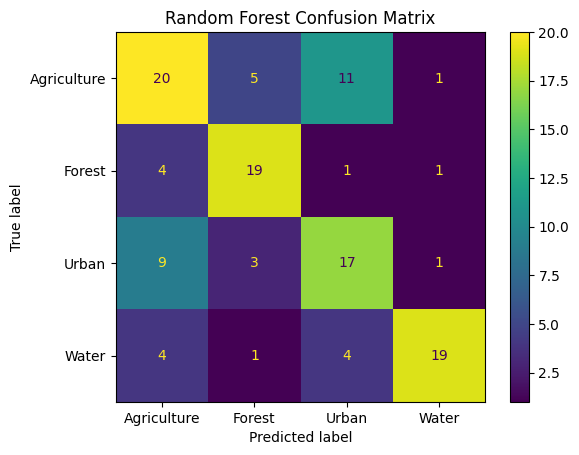

In [22]:
plt.figure(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

**การแสดงผลข้อมูล**

* สร้างแผนที่แสดงผลการจำแนกพื้นที่

In [23]:
# ดึง spatial dimensions
rows, cols = red.shape

# Define map จาก feature names ที่ผ่านการทำ feature selection
feature_map = {
    'B8': nir,
    'B11': swir1,
    'NDVI': ndvi
}

# สร้าง list bands to stack
bands_to_stack = []
for feature_name in selected_features:
    if feature_name in feature_map:
        bands_to_stack.append(feature_map[feature_name])
    else:
        print(f"Warning: Feature '{feature_name}' not found in feature_map.")

# Stack feature ที่เลือก
stack = np.stack(bands_to_stack, axis=-1)

# ลด resolution
stack_small = stack[::4, ::4, :]   # ลด 4 เท่า

In [24]:
# Reshape stack เป็น 2 มิติ (pixels, features)
flat = stack.reshape(-1, len(selected_features))

# แปลงเป็น dataframe ด้วย training feature names
flat_df = pd.DataFrame(flat, columns=selected_features)

In [25]:
# ขั้นตอน predict
chunk_size = 10000  # จำนวน pixel ต่อรอบ

pred_list = []

for i in range(0, len(flat_df), chunk_size):

    batch = flat_df.iloc[i:i+chunk_size]

    batch_pred = rf.predict(batch)

    pred_list.append(batch_pred)

pred = np.concatenate(pred_list)

In [26]:
# ลบตัวแปรที่ไม่ใช้เพื่อประหยัด RAM
del flat_df
gc.collect()

6331

In [27]:
# Reshape prediction กลับเป็น 2 มิติ
classified = pred.reshape(rows, cols)

# ลบตัวแปรที่ไม่ใช้เพื่อประหยัด RAM
del pred_list
gc.collect()

print(f"Successfully generated classified array with shape: {classified.shape}")

Successfully generated classified array with shape: (10302, 9964)


In [28]:
# สร้าง unique_classes เพื่อแสดงแถบสีด้านข้าง map
unique_classes = np.unique(classified)

numeric_classified = np.zeros_like(classified, dtype=int)

for i, cls in enumerate(unique_classes):
    numeric_classified[classified == cls] = i

    print(f"Class {i}: {cls}")

Class 0: Agriculture
Class 1: Forest
Class 2: Urban
Class 3: Water


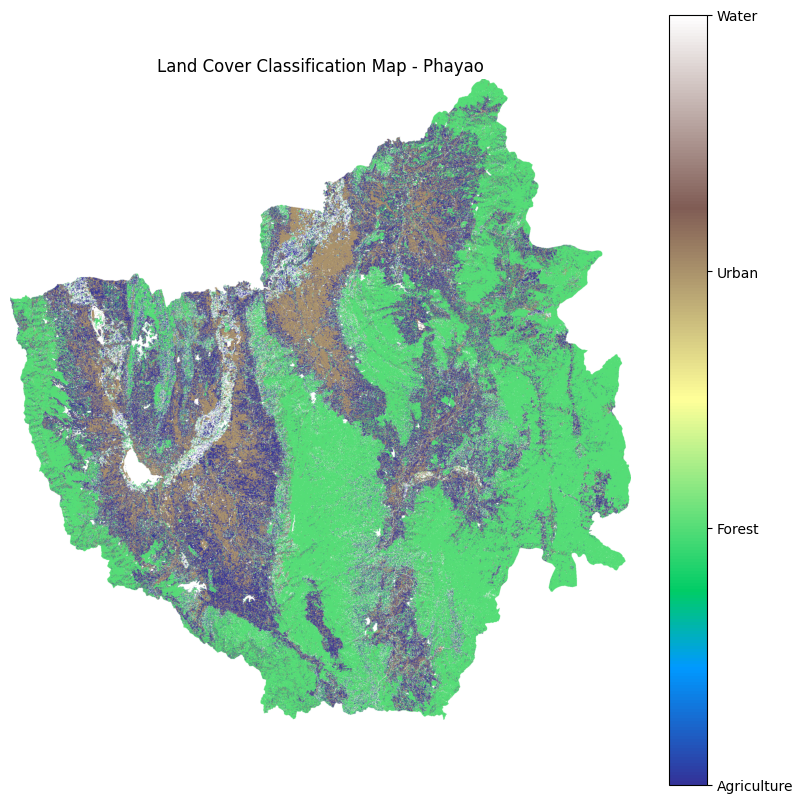

In [36]:
# สร้าง Classification Map
plt.figure(figsize=(10,10))
plt.imshow(numeric_classified[::4, ::4], cmap="terrain")  # ลด resolution 4 เท่า
plt.title("Land Cover Classification Map - Phayao")

# เพิ่มการตั้งค่า Colorbar ให้แสดงชื่อ Class
cbar = plt.colorbar(ticks=range(len(unique_classes)))
cbar.ax.set_yticklabels(unique_classes)

plt.axis("off")
plt.show()


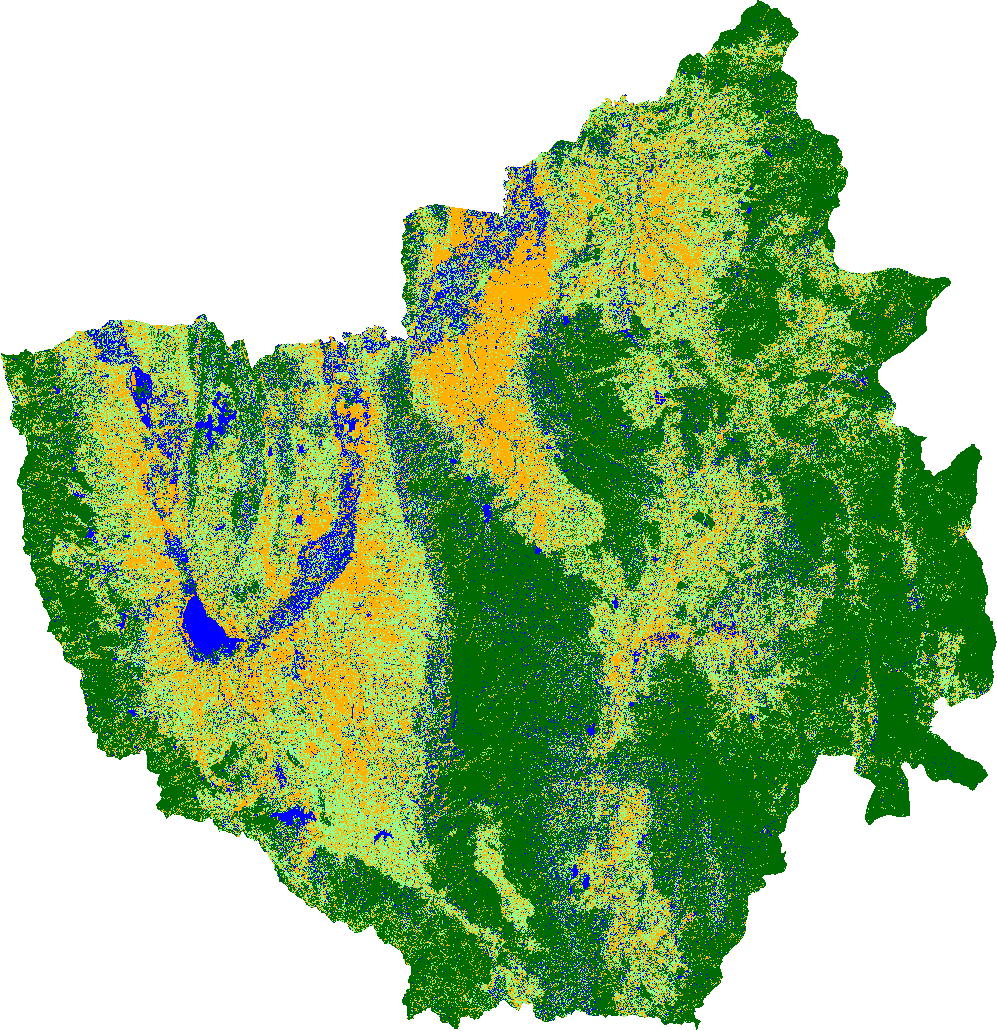

In [37]:
# สร้าง Interactive Map

# โหลด SHAPEFILE ขอบเขตจังหวัด
roi = gpd.read_file("/content/drive/MyDrive/Data for program dev/lab_4/Phayao_bound/34_base2_phayao.shp")  # 🔥 ใส่ path ของคุณ

# เตรียมข้อมูลที่ classification ไว้
class_to_id = {
    "Agriculture": 0,
    "Forest": 1,
    "Urban": 2,
    "Water": 3
}

numeric_classified = np.vectorize(class_to_id.get)(classified).astype(float)

# MASK ด้วย shapefile
with rasterio.open(raster_path) as src:
    transform = src.transform
    raster_crs = src.crs

# แปลง CRS ให้ตรง raster
roi = roi.to_crs(raster_crs)

mask = geometry_mask(
    roi.geometry,
    transform=transform,
    invert=True,
    out_shape=numeric_classified.shape
)

data = numeric_classified.copy()
data[~mask] = np.nan   # ตัดนอกพื้นที่

# ลด resolution (กัน RAM เกิน)
data = data[::10, ::10]

# ดึงขอบเขตจาก shapefile
with rasterio.open(raster_path) as src:
    left, bottom, right, top = transform_bounds(
        src.crs, "EPSG:4326", *src.bounds
    )

# สร้าง Satellite Map
center_lat = (top + bottom) / 2
center_lon = (left + right) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=9,
    tiles=None
)

folium.TileLayer(
    tiles="Esri.WorldImagery",
    name="Satellite"
).add_to(m)

# IMAGE OVERLAY
cmap = colors.ListedColormap([
    "lightgreen",   # Agriculture
    "darkgreen",    # Forest
    "orange",       # Urban
    "blue"          # Water
])

img = data.copy()

# กัน All-NaN error
if np.all(np.isnan(img)):
    raise ValueError("All data is NaN → CRS ไม่ตรง หรือ shapefile ไม่ overlap raster")

denom = (np.nanmax(img) - np.nanmin(img))
img_norm = (img - np.nanmin(img)) / denom if denom != 0 else img

img_color = cmap(img_norm)

# ทำให้ NaN โปร่งใส
img_color[np.isnan(img)] = [0, 0, 0, 0]

# เพิ่มลงใน MAP
folium.raster_layers.ImageOverlay(
    image=img_color,
    bounds=[[bottom, left], [top, right]],
    opacity=0.6
).add_to(m)

# เพิ่ม SHAPEFILE ขอบเขต
roi_4326 = roi.to_crs(epsg=4326)

folium.GeoJson(
    roi_4326,
    name="Boundary",
    style_function=lambda x: {
        "color": "yellow",
        "weight": 2,
        "fillOpacity": 0
    }
).add_to(m)

# LEGEND
legend = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 180px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding:10px;
">

<b>Land Cover</b><br>

<span style="color:lightgreen;">■</span> Agriculture<br>
<span style="color:darkgreen;">■</span> Forest<br>
<span style="color:orange;">■</span> Urban<br>
<span style="color:blue;">■</span> Water

</div>
"""

m.get_root().html.add_child(folium.Element(legend))

m

[ลิงก์สำหรับเปิด Inteactive Map ใน GitHub](https://gustkt.github.io/GE337_Programming_Dev/Land_Cover_RF_Classification_Map_Phayao.html)

* วิเคราะห์ความแม่นยำของแบบจำลอง

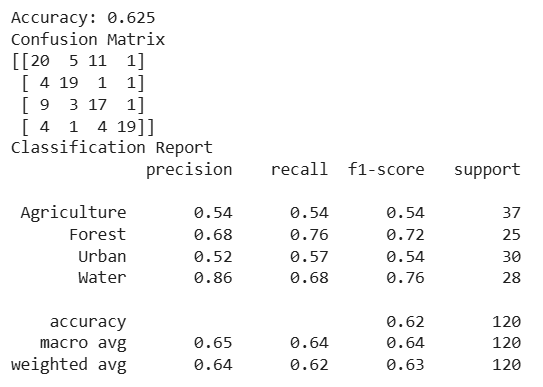

จาก Confusion Matrix และ Classification Report ของ RF พบว่าค่า Accuracy อยู่ที่ 0.625 ซึ่งเป็นค่าที่ต่ำไม่สามารถนำไปใช้อ้างอิงได้ และเมื่อวิเคราะห์ราย class พบว่า Agriculture มีค่า precision/recall อยู่ที่ 0.54 ซึ่งต่ำมากเช่นเดียวกัน มีการแปลผิดเป็น Urban อยู่ 11 จุด คลาส Forest มีค่า f1-score 0.72 ถือว่าพอใช้ ในขณะที่ Urban f1-score อยู่ที่ 0.54 ซึ่งเป็นระดับที่ต่ำมาก และ class Water precision เท่ากับ 0.86 ดีที่สุดจากทุกคลาส

โดยสรุปจุดแข็งของ RF ในการ classification ครั้งนี้ สามารถจัดการคลาส Water/Forest ได้ดี เนื่องจากเลือก feature selection มา 3 bands คือ NIR, SWIR1, NDVI ซึ่งจำแนกพืช และความชื้นได้ดี

# Case 2 : SVM

* แบ่งชุดข้อมูลเป็น Training และ Testing Set

In [29]:
X = df[["B2","B3","B4","B8","B11","NDVI"]]
y = df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

* ปรับขนาดข้อมูลและเลือก Features ที่สำคัญ

In [30]:
# ปรับขนาดข้อมูล
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
selector = SelectKBest(score_func=f_classif, k=6)
X_train_sel = selector.fit_transform(X_train_scaled, y_train)
X_test_sel = selector.transform(X_test_scaled)

print("Selected Features:", X.columns[selector.get_support()])

Selected Features: Index(['B2', 'B3', 'B4', 'B8', 'B11', 'NDVI'], dtype='object')


In [32]:
# ดู scores ของแต่ละ features
scores = selector.scores_

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': scores
}).sort_values(by='Score', ascending=False)

print(feature_scores)

  Feature      Score
4     B11  99.330046
3      B8  80.813941
5    NDVI  75.646871
2      B4  35.701622
0      B2  34.278661
1      B3  28.840329


* ใช้ Grid Search เพื่อปรับพารามิเตอร์ของแบบจำลอง

In [33]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"]
}
svm = SVC()

grid = GridSearchCV(svm, param_grid, cv=5, scoring="accuracy")
grid.fit(X_train_sel, y_train)

print("Best Params:", grid.best_params_)

Best Params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


* ประเมินผลแบบจำลองด้วยค่า Accuracy, Confusion Matrix และ Classification Report

In [34]:
y_pred = grid.predict(X_test_sel)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7083333333333334

Classification Report:

              precision    recall  f1-score   support

 Agriculture       0.62      0.68      0.65        37
      Forest       0.66      0.92      0.77        25
       Urban       0.81      0.57      0.67        30
       Water       0.83      0.71      0.77        28

    accuracy                           0.71       120
   macro avg       0.73      0.72      0.71       120
weighted avg       0.73      0.71      0.71       120


Confusion Matrix:

[[25  6  2  4]
 [ 2 23  0  0]
 [ 8  5 17  0]
 [ 5  1  2 20]]


<Figure size 600x600 with 0 Axes>

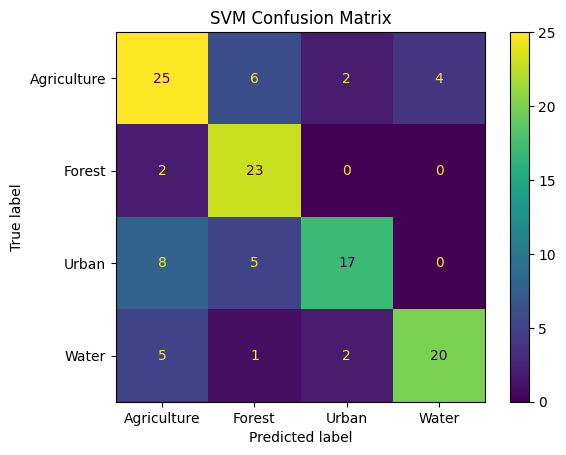

In [35]:
plt.figure(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("SVM Confusion Matrix")
plt.show()

**การแสดงผลข้อมูล**

* สร้างแผนที่แสดงผลการจำแนกพื้นที่

In [36]:
# ดึง spatial dimensions
rows, cols = red.shape

# Define map จาก feature names ที่ผ่านการทำ feature selection
feature_map = {
    'B2': blue,
    'B3': green,
    'B4': red,
    'B8': nir,
    'B11': swir1,
    'NDVI': ndvi
}

# สร้าง list bands to stack
bands_to_stack = []
for feature_name in selected_features:
    if feature_name in feature_map:
        bands_to_stack.append(feature_map[feature_name])
    else:
        print(f"Warning: Feature '{feature_name}' not found in feature_map.")

# Stack feature ที่เลือก
stack = np.stack(bands_to_stack, axis=-1)

# ลด resolution
stack_small = stack[::4, ::4, :]   # ลด 4 เท่า

In [37]:
# Reshape stack เป็น 2 มิติ (pixels, features)
flat = stack.reshape(-1, len(selected_features))

# แปลงเป็น dataframe ด้วย training feature names
flat_df = pd.DataFrame(flat, columns=selected_features)

In [38]:
chunk_size = 10000  # จำนวน pixel ต่อรอบ

pred_list = []

for i in range(0, len(flat_df), chunk_size):

    batch = flat_df.iloc[i:i+chunk_size]

    batch_pred = rf.predict(batch)

    pred_list.append(batch_pred)

pred = np.concatenate(pred_list)

In [39]:
# ลบตัวแปรที่ไม่ใช้เพื่อประหยัด RAM
del flat_df
gc.collect()

46

In [40]:
# Reshape prediction กลับเป็น 2 มิติ
classified = pred.reshape(rows, cols)

# ลบตัวแปรที่ไม่ใช้เพื่อประหยัด RAM
del pred_list
gc.collect()

print(f"Successfully generated classified array with shape: {classified.shape}")

Successfully generated classified array with shape: (10302, 9964)


In [41]:
# สร้าง unique_classes เพื่อแสดงแถบสีด้านข้าง map
unique_classes = np.unique(classified)

numeric_classified = np.zeros_like(classified, dtype=int)

for i, cls in enumerate(unique_classes):
    numeric_classified[classified == cls] = i

    print(f"Class {i}: {cls}")

Class 0: Agriculture
Class 1: Forest
Class 2: Urban
Class 3: Water


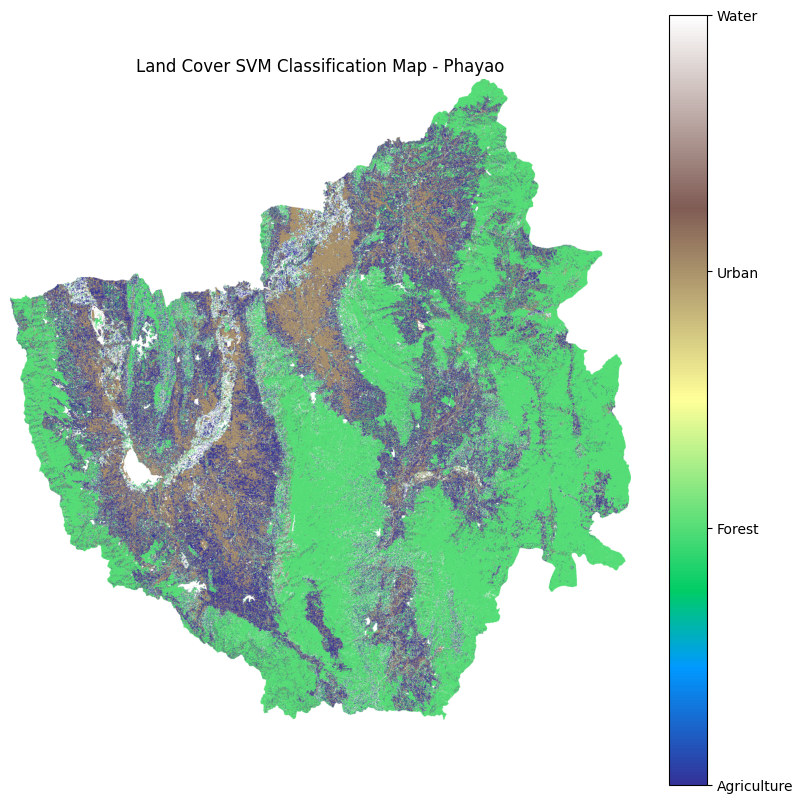

In [44]:
# สร้าง Classification Map
plt.figure(figsize=(10,10))
plt.imshow(numeric_classified[::4, ::4], cmap="terrain")  # ลด resolution 4 เท่า
plt.title("Land Cover SVM Classification Map - Phayao")

# เพิ่มการตั้งค่า Colorbar ให้แสดงชื่อ Class
cbar = plt.colorbar(ticks=range(len(unique_classes)))
cbar.ax.set_yticklabels(unique_classes)

plt.axis("off")
plt.show()


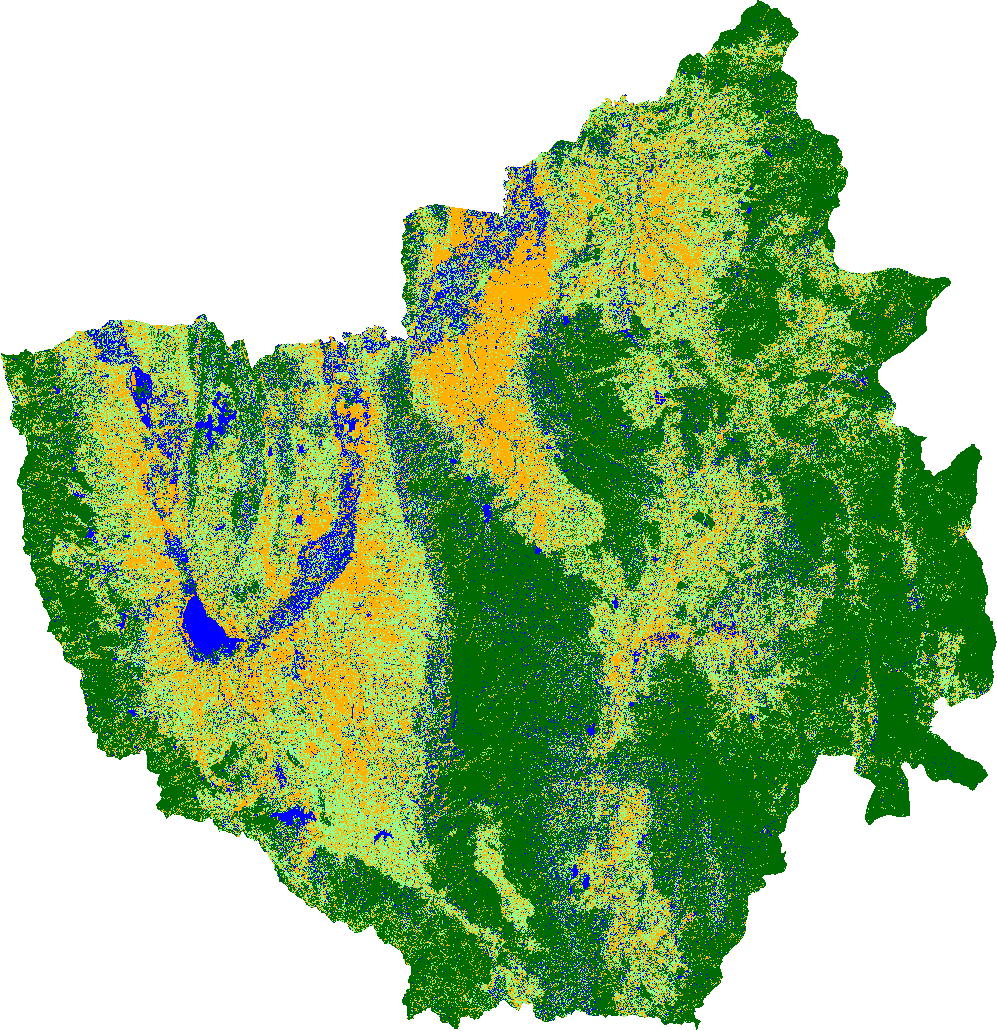

In [43]:
# สร้าง Interactive Map

# โหลด SHAPEFILE ขอบเขตจังหวัด
roi = gpd.read_file("/content/drive/MyDrive/Data for program dev/lab_4/Phayao_bound/34_base2_phayao.shp")

# เตรียมข้อมูลที่ classification ไว้
class_to_id = {
    "Agriculture": 0,
    "Forest": 1,
    "Urban": 2,
    "Water": 3
}

numeric_classified = np.vectorize(class_to_id.get)(classified).astype(float)

# MASK ด้วย shapefile
with rasterio.open(raster_path) as src:
    transform = src.transform
    raster_crs = src.crs

# แปลง CRS ให้ตรง raster
roi = roi.to_crs(raster_crs)

mask = geometry_mask(
    roi.geometry,
    transform=transform,
    invert=True,
    out_shape=numeric_classified.shape
)

data = numeric_classified.copy()
data[~mask] = np.nan   # ตัดนอกพื้นที่

# ลด resolution (กัน RAM เกิน)
data = data[::10, ::10]

# ดึงขอบเขตจาก shapefile
with rasterio.open(raster_path) as src:
    left, bottom, right, top = transform_bounds(
        src.crs, "EPSG:4326", *src.bounds
    )

# สร้าง Satellite Map
center_lat = (top + bottom) / 2
center_lon = (left + right) / 2

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=9,
    tiles=None
)

folium.TileLayer(
    tiles="Esri.WorldImagery",
    name="Satellite"
).add_to(m)

# IMAGE OVERLAY
cmap = colors.ListedColormap([
    "lightgreen",   # Agriculture
    "darkgreen",    # Forest
    "orange",       # Urban
    "blue"          # Water
])

img = data.copy()

# กัน All-NaN error
if np.all(np.isnan(img)):
    raise ValueError("All data is NaN → CRS ไม่ตรง หรือ shapefile ไม่ overlap raster")

denom = (np.nanmax(img) - np.nanmin(img))
img_norm = (img - np.nanmin(img)) / denom if denom != 0 else img

img_color = cmap(img_norm)

# ทำให้ NaN โปร่งใส
img_color[np.isnan(img)] = [0, 0, 0, 0]

# เพิ่มลงใน MAP
folium.raster_layers.ImageOverlay(
    image=img_color,
    bounds=[[bottom, left], [top, right]],
    opacity=0.6
).add_to(m)

# เพิ่ม SHAPEFILE ขอบเขต
roi_4326 = roi.to_crs(epsg=4326)

folium.GeoJson(
    roi_4326,
    name="Boundary",
    style_function=lambda x: {
        "color": "yellow",
        "weight": 2,
        "fillOpacity": 0
    }
).add_to(m)

# LEGEND
legend = """
<div style="
position: fixed;
bottom: 40px;
left: 40px;
width: 180px;
background-color: white;
border:2px solid grey;
z-index:9999;
font-size:14px;
padding:10px;
">

<b>Land Cover</b><br>

<span style="color:lightgreen;">■</span> Agriculture<br>
<span style="color:darkgreen;">■</span> Forest<br>
<span style="color:orange;">■</span> Urban<br>
<span style="color:blue;">■</span> Water

</div>
"""

m.get_root().html.add_child(folium.Element(legend))

m

[ลิงก์สำหรับเปิด Interactive Map ใน GitHub](https://gustkt.github.io/GE337_Programming_Dev/Land_Cover_SVM_Classification_Map_Phayao.html)

* วิเคราะห์ความแม่นยำของแบบจำลอง

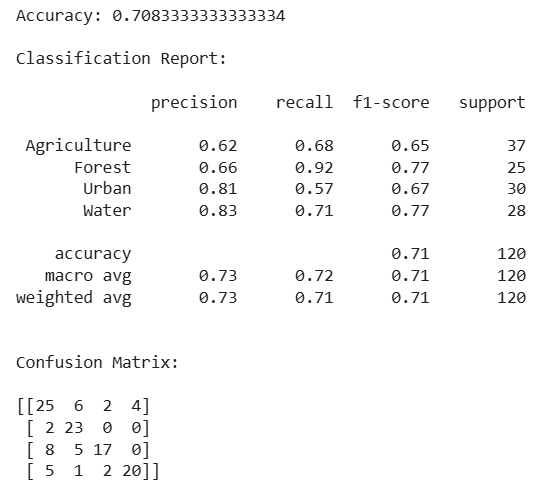

จาก Confusion Matrix และ Classification Report ของ SVM พบว่าค่า Accuracy อยู่ที่ประมาณ 0.708 ซึ่งเป็นค่าที่ค่อนข้างดีสามารถนำไปใช้อ้างอิงได้ และเมื่อวิเคราะห์ราย class พบว่า Agriculture มีค่า precision/recall อยู่ที่ 0.62 กับ 0.68 ตามลำดับ มีปัญหาสับสนในการจำแนกเป็น Forest/Water เนื่องจากมี spectral signature ที่ใกล้กัน และมี NDVI สูงเหมือนกัน class Forest มี recall 0.92 เป็นค่าที่ดีมากเนื่องจากป่ามักมีเรือนยอดสูง ค่า NDVI จึงสูงไปด้วย รวมถึงมี SWIR1 ช่วยแยกความชื้น คลาส Water precision/recall อยู่ที่ 0.83 และ 0.71 ตามลำดับ เนื่องจากมี spectral signature ชัดเจน (NDVI ต่ำ และ SWIR ต่ำ) ในขณะที่ class Urban คือจุดอ่อนหลักของ classification ครั้งนี้ มี recall เท่ากับ 0.57 มีการจำแนกผิดไปเป็น Agriculture

โดยสรุปจุดแข็งของ SVM ในการ classification ครั้งนี้ที่สามารถจำแนกได้ดีเนื่องจากใช้ band ทุก band ในการจำแนกแต่ก็มีความ sensitive กับบางคลาส เช่น Urban กับ Ageiculture ที่แยกได้ไม่ชัดเจน

**คำถามท้าย Lab**

**1. ทำไมการเลือก Features ที่เหมาะสมจึงสำคัญใน Machine Learning?**

**คำตอบ** เพราะการเลือก Features ที่เหมาะสมเป็นวิธีการดึงตัวแทนของข้อมูลที่เกี่ยวข้องกับลักษณะพื้นที่จริง เช่น ค่า spectral band ของภาพถ่ายดาวเทียม หรือค่า NDVI จะช่วยให้ model สามารถแยกประเภทของพื้นที่ได้แม่นยำมากขึ้น ในทางกลับกันถ้าใช้ Features ที่ไม่เกี่ยวข้องหรือมี noise รบกวนมากอาจทำให้ model เรียนรู้รูปแบบได้ไม่ถูกต้องส่งผลให้ความแม่นยำลดลงและอาจเกิดปัญหา overfitting หรือ underfitting ได้

**2. เปรียบเทียบระหว่าง Random Forest และ SVM ในบริบทของปัญหานี้**

**คำตอบ** Random Forest

ข้อดี
* สามารถจัดการกับข้อมูลซับซ้อนได้ดี
* ทนต่อ noise และ outliers
* ไม่จำเป็นต้องทำ normalization ของข้อมูล
* สามารถบอก feature importance ได้

ข้อเสีย
* ใช้หน่วยความจำมากถ้าใช้ข้อมูลขนาดใหญ่
* อาจเกิด overfitting ได้

SVM

ข้อดี
* ทำงานได้ดีเมื่อข้อมูลมีขนาดไม่ใหญ่มาก
* สามารถจำแนกข้อมูลที่มี boundary ซับซ้อนได้ด้วย kernal

ข้อเสีย
* ต้องทำ feature scaling ก่อนใช้งาน
* การเลือกพารามิเตอร์ เช่น C, gamma มีผลต่อผลลัพธ์มาก
* ใช้เวลาคำนวณมากขึ้นเมื่อข้อมูลมีจำนวนมาก

**3. การใช้ NDVI เพียงอย่างเดียวเพียงพอสำหรับจำแนกประเภทพื้นที่หรือไม่? ทำไม?**

**คำตอบ** โดยทั่วไปใช้ NDVI ไม่เพียงพอ เพราะ NDVI ถูกออกแบบมาเพื่อแสดงความหนาแน่นของพืชพรรณ เหมาะสำหรับการแยกพื้นที่พืชพรรณกับพืชที่ที่ไม่ใช่พืช ไม่สามารถแยกประเภทของพื้นที่อื่น ๆ ได้อย่างชัดเจน ดังนั้นจึงควรใช้ spectral band หลายช่วงคลื่นร่วมกับ NDVI เพื่อให้ model มีข้อมูลมากพอในการ classification ได้อย่างถูกต้อง

**4. หากต้องการเพิ่มความแม่นยำของแบบจำลอง ควรทำอย่างไร?**

**คำตอบ**
* เพื่มจำนวน training samples เพื่อให้ model เรียนรู้รูปแบบข้อมูลได้ดีขึ้น
* ใช้ features ร่วมเพิ่มเติม เช่น index หรือ spectral band อื่น ๆ
* ปรับพารามิเตอร์ของ model ด้วย Grid Search หรือ Cross Validation
* ปรับปรุงคุณภาพของข้อมูล เช่น ลด noise หรือใช้ภาพถ่ายดาวเทียมที่มีเมฆน้อย
* ใช้ methods อื่นร่วม เช่น Gradient Boosting

**5. ปัจจัยใดที่อาจทำให้แบบจำลองจำแนกประเภทของพื้นที่ผิดพลาด?**

**คำตอบ**
* Spectral Singnature คล้ายกัน เช่น เขตเมือง กับ bare land
* จำนวน training samples ไม่เพียงพอ หรือไม่ครอบคลุมทุกประเภทพื้นที่
* ตำแหน่ง samples ไม่ตรงกับ pixel ของภาพ
* ข้อมูลภาพมีเมฆ หรือ noise
* Spatial resolution ของภาพละเอียดไม่เพียงพอทำให้ใน 1 pixel มีหลาย landuse/landcover